# TFLite Training Export + XAI on Edge

We re-export the Keras LSTM with 5 tflite signatures (`train`, `infer`, `parameters`, `restore`, `explain`) so it can participate in Federated Learning on-device and produce gradient-based feature explanations

Thus, we demonstrate the Python XAI module (vanilla gradient saliency) and verify that the TFLite `explain` signature produces identical importances.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from src.config import MODELS_DIR, PROCESSED_DIR
from src.features import SUBWINDOW_FEATURE_NAMES
from src.train import load_npz
from src.xai import gradient_feature_importance, top_k_features, normalise
from src.tflite_training_export import export_trainable_tflite

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## Train the binary classifier

Trains the LSTM from scratch with `--binary` so the output layer has exactly **2 nodes**:
`0 = normal` (WESAD baseline, label 1), `1 = stress` (WESAD label 2).
Amusement windows are excluded entirely (see `KEEP_LABELS` in `src/config.py`).

Use `--mode loso` (full Leave-One-Subject-Out, 6 min) for the production model,
or `--mode holdout` (1 min) for a quick smoke-test.


In [2]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "src.train", "--mode", "loso", "--binary"],
    cwd=str(pathlib.Path.cwd().parent),
    capture_output=True, text=True,
)
print(result.stdout[-4000:] if len(result.stdout) > 4000 else result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1500:])


8 - 0s - 11ms/step - accuracy: 1.0000 - loss: 0.0157
Epoch 35/60
28/28 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0155
Epoch 36/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0151
Epoch 37/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0148
Epoch 38/60
28/28 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0146
Epoch 39/60
28/28 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0143
Epoch 40/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0141
Epoch 41/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0141
Epoch 42/60
28/28 - 0s - 10ms/step - accuracy: 1.0000 - loss: 0.0139
Epoch 43/60
28/28 - 0s - 11ms/step - accuracy: 0.9994 - loss: 0.0192
Epoch 44/60
28/28 - 0s - 10ms/step - accuracy: 0.9937 - loss: 0.0280
Epoch 45/60
28/28 - 0s - 9ms/step - accuracy: 0.9977 - loss: 0.0239
Epoch 46/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0143
Epoch 47/60
28/28 - 0s - 9ms/step - accuracy: 1.0000 - loss: 0.0139
Epoch 48/60
28/28 - 0s - 10ms/step - accuracy: 1.0000 - l

## Export 5-signature trainable TFLite + copy to mobile assets


In [3]:
tflite_path = export_trainable_tflite()
print('Binary TFLite size:', tflite_path.stat().st_size / 1024, 'KB')

# Copy the new binary TFLite into the mobile assets folder
# so the next Android build picks it up automatically.
import shutil
asset_dst = (pathlib.Path.cwd().parent.parent
             / 'mobile' / 'src' / 'main' / 'assets' / 'mindwave_stress.tflite')
shutil.copy(tflite_path, asset_dst)
print('Copied to', asset_dst)


INFO:tensorflow:Assets written to: C:\Users\daniion6\AppData\Local\Temp\tmpm3u_teve\assets


INFO:tensorflow:Assets written to: C:\Users\daniion6\AppData\Local\Temp\tmpm3u_teve\assets


Trainable TFLite (902.2 KB) at C:\Users\daniion6\AndroidStudioProjects\MindWave\ml\models\mindwave_stress_trainable.tflite
Binary TFLite size: 902.19140625 KB
Copied to c:\Users\daniion6\AndroidStudioProjects\MindWave\mobile\src\main\assets\mindwave_stress.tflite


## Sanity-check: run `infer` and `explain` via the tf.Module

The exported `.tflite` uses `SELECT_TF_OPS` (for GradientTape ops like `ReluGrad`). The Python TFLite runtime does not ship the Flex delegate on Windows, so we verify the identical computation through the `TrainableModule` tf.Module instead. On Android, the full `.tflite` is loaded with the `tensorflow-lite-select-tf-ops` AAR.

In [4]:
# Load a sample window from the processed dataset.
X, y, sids, _ = load_npz(PROCESSED_DIR / 'wesad_wrist.npz')
# Binarize labels to match the binary model: 0=non_stress, 1=stress
y = (y == 1).astype(np.int64)
print(f'Dataset: {X.shape}  classes: non_stress={( y==0).sum()}  stress={(y==1).sum()}')

import joblib
scaler = joblib.load(MODELS_DIR / 'scaler.pkl')
sample_raw = X[0:1]  # (1, 12, F)
n, t, f = sample_raw.shape
sample = scaler.transform(sample_raw.reshape(-1, f)).reshape(n, t, f).astype(np.float32)

# Verify signatures via the TrainableModule
from src.tflite_training_export import TrainableModule
_verify_model = tf.keras.models.load_model(MODELS_DIR / 'mindwave_stress.keras', compile=False)
assert _verify_model.output_shape[-1] == 2, (
    f"Expected binary model (2 outputs), got {_verify_model.output_shape[-1]}. "
    "Run Steps 1 & 2 above first."
)
module = TrainableModule(_verify_model, learning_rate=1e-3)

# Infer
out = module.infer(tf.constant(sample))
probs = out['logits'].numpy()[0]
print(f'Infer → non_stress={probs[0]:.4f}  stress={probs[1]:.4f}')

# Explain
out_xai = module.explain(tf.constant(sample))
importances_tflite = out_xai['importances'].numpy()[0]
print(f'Explain importances (first 5): {importances_tflite[:5]}')
print(f'Max importance: {importances_tflite.max():.6f}')


Dataset: (1738, 12, 23)  classes: non_stress=1124  stress=614
Infer → non_stress=0.0376  stress=0.9624
Explain importances (first 5): [0.07854325 0.0408589  0.04403434 0.01377988 0.00926293]
Max importance: 0.081885


## Python XAI reference (Keras eager) and comparison

In [5]:
model = tf.keras.models.load_model(MODELS_DIR / 'mindwave_stress.keras', compile=False)
imp_dict = gradient_feature_importance(model, sample[0])
top = top_k_features(imp_dict, k=5)
print('Top-5 features:', top)

# Compare TFLite vs Keras importances.
imp_keras = np.array([imp_dict[n] for n in SUBWINDOW_FEATURE_NAMES])
diff = np.abs(imp_keras - importances_tflite)
print(f'Max abs diff (Keras vs TFLite explain): {diff.max():.6f}')

Top-5 features: [('eda_scr_peaks', 0.08188480883836746), ('hrv_meanNN', 0.07854325324296951), ('eda_scr_auc', 0.06503911316394806), ('temp_std', 0.05434562638401985), ('temp_max', 0.05114731565117836)]
Max abs diff (Keras vs TFLite explain): 0.000000


## Visualise feature importances for a single prediction

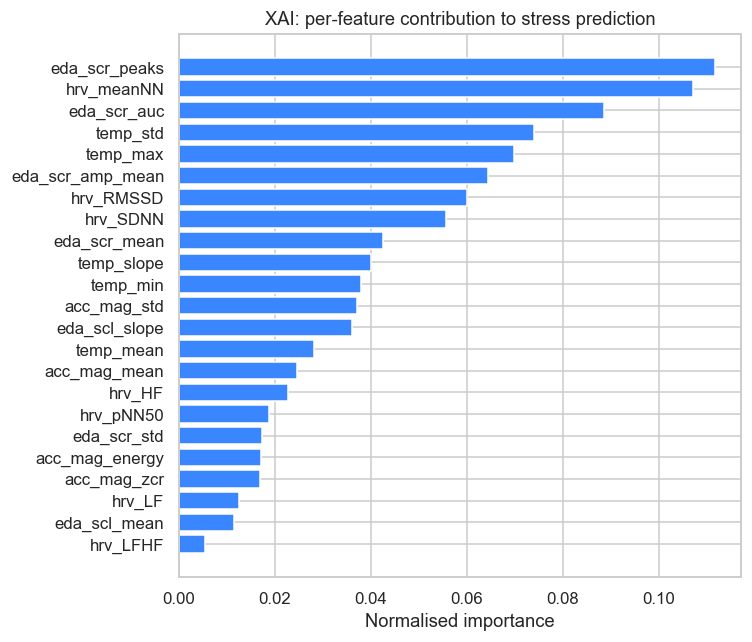

In [6]:
imp_norm = normalise(imp_dict)
df = (pd.DataFrame({'feature': list(imp_norm.keys()), 'importance': list(imp_norm.values())})
       .sort_values('importance', ascending=True))
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(df['feature'], df['importance'], color='#3a86ff')
ax.set_xlabel('Normalised importance'); ax.set_title('XAI: per-feature contribution to stress prediction')
fig.tight_layout()

## Batch XAI: average importances per class

normal: max=0.001638  min=0.000079
stress: max=0.002088  min=0.000168


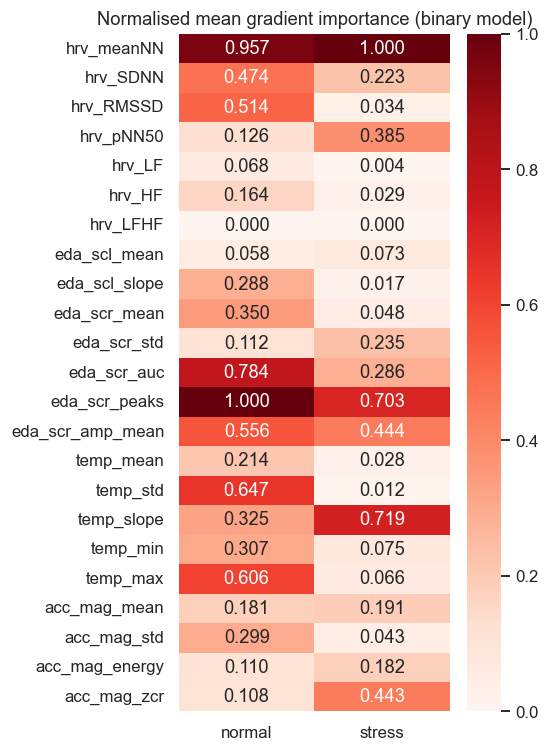

In [7]:
from src.config import LABEL_NAMES  # {0: 'normal', 1: 'stress'}

# Take 50 samples per class (y is already binarized above).
raw_imps = {}
for cls, label in LABEL_NAMES.items():
    idx = np.where(y == cls)[0][:50]
    if len(idx) == 0:
        print(f'Warning: no samples for class {cls} ({label})')
        continue
    batch_raw = X[idx]
    n2, t2, f2 = batch_raw.shape
    batch = scaler.transform(batch_raw.reshape(-1, f2)).reshape(n2, t2, f2).astype(np.float32)
    imps = [
        [gradient_feature_importance(model, batch[i])[fn] for fn in SUBWINDOW_FEATURE_NAMES]
        for i in range(len(batch))
    ]
    raw_imps[label] = np.mean(imps, axis=0)
    print(f'{label}: max={raw_imps[label].max():.6f}  min={raw_imps[label].min():.6f}')

# Normalise each column to [0, 1] so the heatmap always shows contrast.
def _minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)

class_imps = {label: _minmax(v) for label, v in raw_imps.items()}

heat_df = pd.DataFrame(class_imps, index=SUBWINDOW_FEATURE_NAMES)
fig, ax = plt.subplots(figsize=(5, 7))
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='Reds', ax=ax)
ax.set_title('Normalised mean gradient importance (binary model)')
fig.tight_layout()
